
TASK 3: CAR PRICE PREDICTION WITH MACHINE LEARNING

AICTE Oasis Infobyte Internship.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# HELPER: Create realistic sample car dataset
def create_sample_data(n=500):
    np.random.seed(42)
    brands = ['Maruti', 'Hyundai', 'Honda', 'Toyota', 'Ford', 'BMW', 'Audi', 'Mercedes']
    fuel_types = ['Petrol', 'Diesel', 'CNG', 'Electric']
    seller_types = ['Dealer', 'Individual', 'Trustmark Dealer']
    transmissions = ['Manual', 'Automatic']
    owners = ['First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner']

    data = []
    for _ in range(n):
        brand = np.random.choice(brands)
        year = np.random.randint(2005, 2023)
        age = 2024 - year
        km = np.random.randint(5000, 200000)
        fuel = np.random.choice(fuel_types, p=[0.5, 0.35, 0.1, 0.05])
        seller = np.random.choice(seller_types, p=[0.45, 0.45, 0.1])
        trans = np.random.choice(transmissions, p=[0.7, 0.3])
        owner = np.random.choice(owners, p=[0.55, 0.3, 0.1, 0.05])
        seats = np.random.choice([5, 6, 7], p=[0.7, 0.1, 0.2])

        # Price logic
        base = 1.5e5 if brand in ['Maruti', 'Hyundai'] else \
               3e5 if brand in ['Honda', 'Toyota', 'Ford'] else 8e5
        price = base * np.exp(-0.08 * age) * np.exp(-0.000003 * km)
        if trans == 'Automatic': price *= 1.12
        if fuel == 'Diesel': price *= 1.08
        if fuel == 'Electric': price *= 1.5
        if owner == 'Second Owner': price *= 0.85
        elif owner == 'Third Owner': price *= 0.72
        elif owner == 'Fourth & Above Owner': price *= 0.55
        price += np.random.normal(0, price * 0.08)
        price = max(50000, price)

        data.append({
            'name': f"{brand} Car {year}",
            'year': year,
            'selling_price': round(price, 0),
            'km_driven': km,
            'fuel': fuel,
            'seller_type': seller,
            'transmission': trans,
            'owner': owner,
            'seats': seats,
            'mileage': round(np.random.uniform(10, 35), 1),
            'engine': np.random.choice([1000, 1200, 1400, 1500, 1800, 2000]),
            'max_power': round(np.random.uniform(60, 250), 1),
        })
    return pd.DataFrame(data)

In [3]:
# 1. LOAD DATASET
print("=" * 60)
print("     CAR PRICE PREDICTION WITH MACHINE LEARNING")
print("=" * 60)

try:
    df = pd.read_csv('car data.csv')
    print("\n[1] Dataset loaded from CSV file.")
except FileNotFoundError:
    try:
        df = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')
        print("\n[1] Dataset loaded from CSV file.")
    except FileNotFoundError:
        print("\n[1] CSV not found — using generated sample data.")
        print("    (Place 'car data.csv' in the same directory for real data.)")
        df = create_sample_data()

print(f"    Shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")

     CAR PRICE PREDICTION WITH MACHINE LEARNING

[1] CSV not found — using generated sample data.
    (Place 'car data.csv' in the same directory for real data.)
    Shape: (500, 12)

First 5 rows:
              name  year  selling_price  km_driven      fuel seller_type  \
0    Audi Car 2019  2019       448499.0     124879    Diesel      Dealer   
1     BMW Car 2010  2010       402916.0      10311  Electric  Individual   
2  Toyota Car 2020  2020       122468.0     195222    Petrol  Individual   
3  Toyota Car 2018  2018       104007.0     179073    Petrol      Dealer   
4  Toyota Car 2022  2022       196159.0      24457    Petrol      Dealer   

  transmission        owner  seats  mileage  engine  max_power  
0       Manual  First Owner      7     10.5    1200      197.2  
1       Manual  First Owner      5     23.1    1200       68.9  
2       Manual  First Owner      5     14.3    1200      240.3  
3       Manual  First Owner      5     22.4    1400      232.8  
4       Manual  Firs

In [4]:
# 2. DATA CLEANING & FEATURE ENGINEERING
print("\n[2] Data Cleaning & Feature Engineering...")

# Rename columns to lowercase for consistency
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

# Identify key columns (handle different dataset formats)
target_col = 'selling_price' if 'selling_price' in df.columns else \
             'price' if 'price' in df.columns else df.select_dtypes(include='number').columns[-1]

year_col = 'year' if 'year' in df.columns else None
km_col = next((c for c in df.columns if 'km' in c or 'kilometer' in c), None)

print(f"    Target column : {target_col}")
print(f"    Year column   : {year_col}")
print(f"    KM column     : {km_col}")

# Create car_age feature
if year_col:
    df['car_age'] = 2024 - df[year_col]

# Clean mileage / engine / power columns (remove units if present)
for col in ['mileage', 'engine', 'max_power']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.extract(r'([\d.]+)').astype(float)

# Drop rows where target is null
df.dropna(subset=[target_col], inplace=True)

# Drop name/model column (too high-cardinality for simple models)
if 'name' in df.columns:
    # Extract brand from name
    df['brand'] = df['name'].str.split().str[0]
    df.drop(columns=['name'], inplace=True)

print(f"    Cleaned shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# Fill remaining NaN with median (numeric) or mode (categorical)
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f"\nStatistical Summary:\n{df[[target_col]].describe()}")


[2] Data Cleaning & Feature Engineering...
    Target column : selling_price
    Year column   : year
    KM column     : km_driven
    Cleaned shape: (500, 13)

Missing values:
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
seats            0
mileage          0
engine           0
max_power        0
car_age          0
brand            0
dtype: int64

Statistical Summary:
       selling_price
count   5.000000e+02
mean    1.547131e+05
std     1.333099e+05
min     5.000000e+04
25%     5.824700e+04
50%     1.081020e+05
75%     1.960285e+05
max     1.022805e+06



[3] Generating EDA Visualizations...
    Saved: car_eda.png
    Saved: car_correlation.png


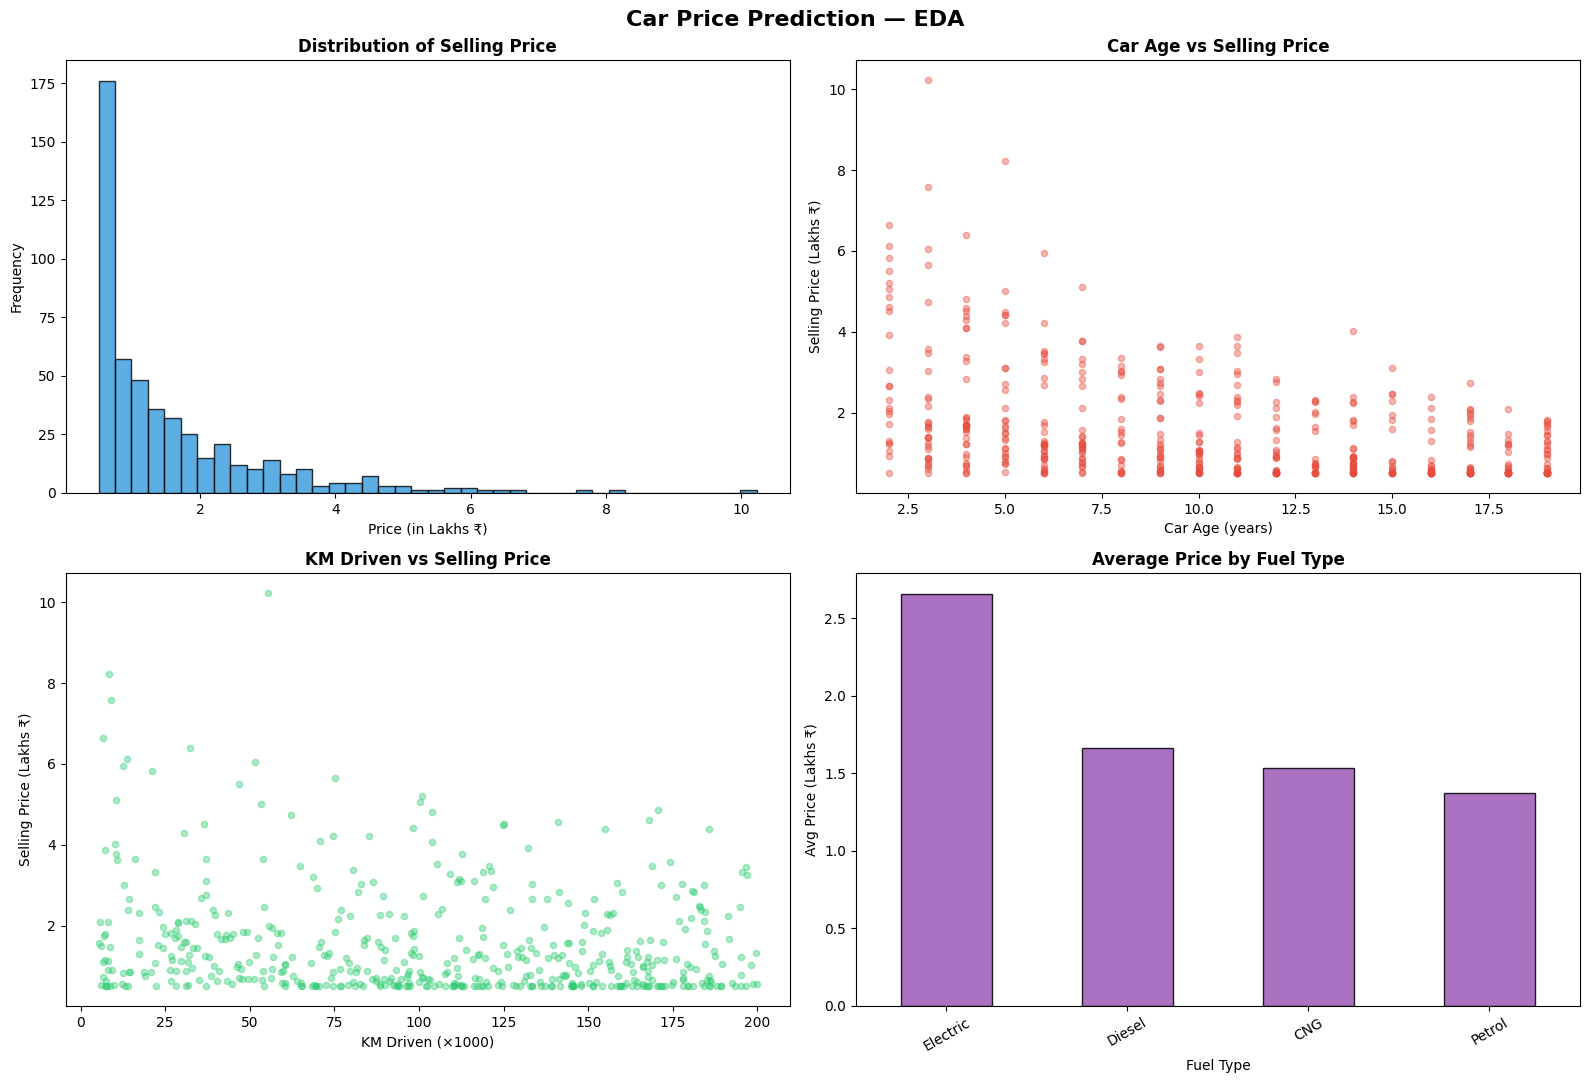

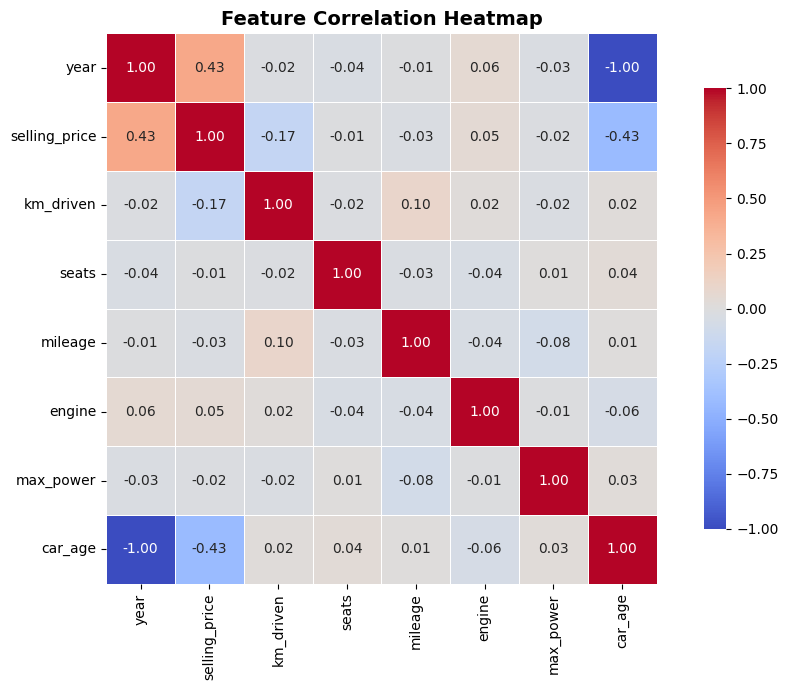

In [11]:
# 3. EDA VISUALIZATIONS
print("\n[3] Generating EDA Visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Car Price Prediction — EDA", fontsize=16, fontweight='bold')

# Price distribution
axes[0, 0].hist(df[target_col] / 1e5, bins=40, color='#3498db', edgecolor='black', alpha=0.8)
axes[0, 0].set_title('Distribution of Selling Price', fontweight='bold')
axes[0, 0].set_xlabel('Price (in Lakhs ₹)')
axes[0, 0].set_ylabel('Frequency')

# Price vs Car Age
if 'car_age' in df.columns:
    axes[0, 1].scatter(df['car_age'], df[target_col] / 1e5, alpha=0.4, color='#e74c3c', s=20)
    axes[0, 1].set_title('Car Age vs Selling Price', fontweight='bold')
    axes[0, 1].set_xlabel('Car Age (years)')
    axes[0, 1].set_ylabel('Selling Price (Lakhs ₹)')

# KM Driven vs Price
if km_col and km_col in df.columns:
    axes[1, 0].scatter(df[km_col] / 1000, df[target_col] / 1e5, alpha=0.4, color='#2ecc71', s=20)
    axes[1, 0].set_title('KM Driven vs Selling Price', fontweight='bold')
    axes[1, 0].set_xlabel('KM Driven (×1000)')
    axes[1, 0].set_ylabel('Selling Price (Lakhs ₹)')

# Average price by fuel type
if 'fuel' in df.columns:
    fuel_avg = df.groupby('fuel')[target_col].mean().sort_values(ascending=False) / 1e5
    fuel_avg.plot(kind='bar', ax=axes[1, 1], color='#9b59b6', edgecolor='black', alpha=0.85)
    axes[1, 1].set_title('Average Price by Fuel Type', fontweight='bold')
    axes[1, 1].set_xlabel('Fuel Type')
    axes[1, 1].set_ylabel('Avg Price (Lakhs ₹)')
    axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('car_eda.png', dpi=150, bbox_inches='tight')
print("    Saved: car_eda.png")

# Correlation Heatmap
numeric_cols = df.select_dtypes(include='number').columns.tolist()
if len(numeric_cols) >= 2:
    plt.figure(figsize=(10, 7))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
    plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('car_correlation.png', dpi=150, bbox_inches='tight')
    print("    Saved: car_correlation.png")

In [6]:
# 4. FEATURE SELECTION & PREPROCESSING
print("\n[4] Preprocessing Features...")

# Select features
drop_cols = [target_col, year_col] if year_col else [target_col]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df[target_col]

categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include='number').columns.tolist()

print(f"    Numerical features : {numerical_cols}")
print(f"    Categorical features: {categorical_cols}")

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"    Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


[4] Preprocessing Features...
    Numerical features : ['km_driven', 'seats', 'mileage', 'engine', 'max_power', 'car_age']
    Categorical features: ['fuel', 'seller_type', 'transmission', 'owner', 'brand']
    Train size: 400, Test size: 100


In [7]:
# 5. MODEL TRAINING & EVALUATION
print("\n[5] Training Multiple Models...")
print("-" * 50)

models = {
    'Linear Regression':    LinearRegression(),
    'Ridge Regression':     Ridge(alpha=1.0),
    'Lasso Regression':     Lasso(alpha=1.0),
    'Decision Tree':        DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    results[name] = {'pipeline': pipe, 'mae': mae, 'rmse': rmse, 'r2': r2, 'y_pred': y_pred}
    print(f"    {name:<22} | MAE: {mae:>10,.0f} | RMSE: {rmse:>12,.0f} | R²: {r2:.4f}")



[5] Training Multiple Models...
--------------------------------------------------
    Linear Regression      | MAE:     45,741 | RMSE:       58,891 | R²: 0.7889
    Ridge Regression       | MAE:     45,174 | RMSE:       58,300 | R²: 0.7932
    Lasso Regression       | MAE:     45,738 | RMSE:       58,888 | R²: 0.7890
    Decision Tree          | MAE:     33,313 | RMSE:       60,588 | R²: 0.7766
    Random Forest          | MAE:     23,807 | RMSE:       38,231 | R²: 0.9110
    Gradient Boosting      | MAE:     23,458 | RMSE:       34,774 | R²: 0.9264



[6] Best Model: Gradient Boosting
    R² Score : 0.9264
    MAE      : ₹23,458
    RMSE     : ₹34,774
    Saved: car_model_results.png


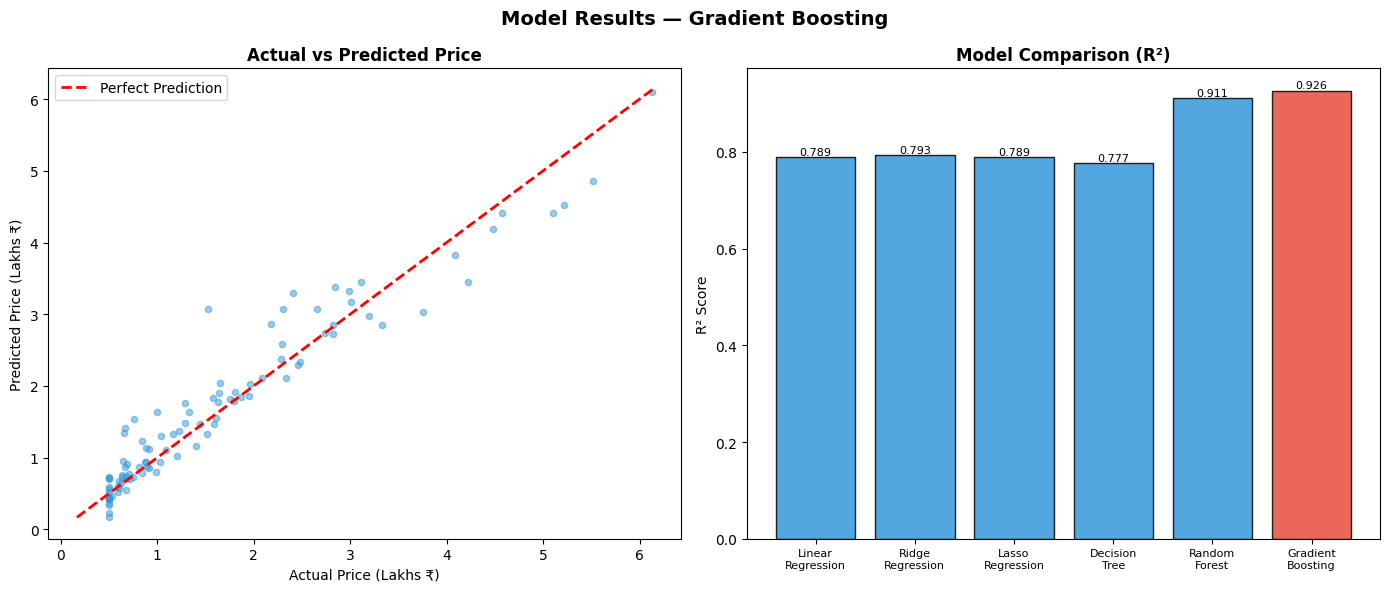

In [12]:
# 6. BEST MODEL
best_name = max(results, key=lambda k: results[k]['r2'])
best = results[best_name]
print(f"\n[6] Best Model: {best_name}")
print(f"    R² Score : {best['r2']:.4f}")
print(f"    MAE      : ₹{best['mae']:,.0f}")
print(f"    RMSE     : ₹{best['rmse']:,.0f}")

# Actual vs Predicted Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Model Results — {best_name}", fontsize=14, fontweight='bold')

axes[0].scatter(y_test / 1e5, best['y_pred'] / 1e5, alpha=0.5, color='#3498db', s=20)
lims = [min(y_test.min(), best['y_pred'].min()) / 1e5,
        max(y_test.max(), best['y_pred'].max()) / 1e5]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (Lakhs ₹)')
axes[0].set_ylabel('Predicted Price (Lakhs ₹)')
axes[0].set_title('Actual vs Predicted Price', fontweight='bold')
axes[0].legend()

# Model comparison (R²)
model_names = list(results.keys())
r2_scores = [results[m]['r2'] for m in model_names]
bar_colors = ['#e74c3c' if m == best_name else '#3498db' for m in model_names]
bars = axes[1].bar(range(len(model_names)), r2_scores, color=bar_colors, edgecolor='black', alpha=0.85)
axes[1].set_xticks(range(len(model_names)))
axes[1].set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=8)
axes[1].set_ylabel('R² Score')
axes[1].set_title('Model Comparison (R²)', fontweight='bold')
for bar, score in zip(bars, r2_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{score:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('car_model_results.png', dpi=150, bbox_inches='tight')
print("    Saved: car_model_results.png")

    Saved: car_feature_importance.png


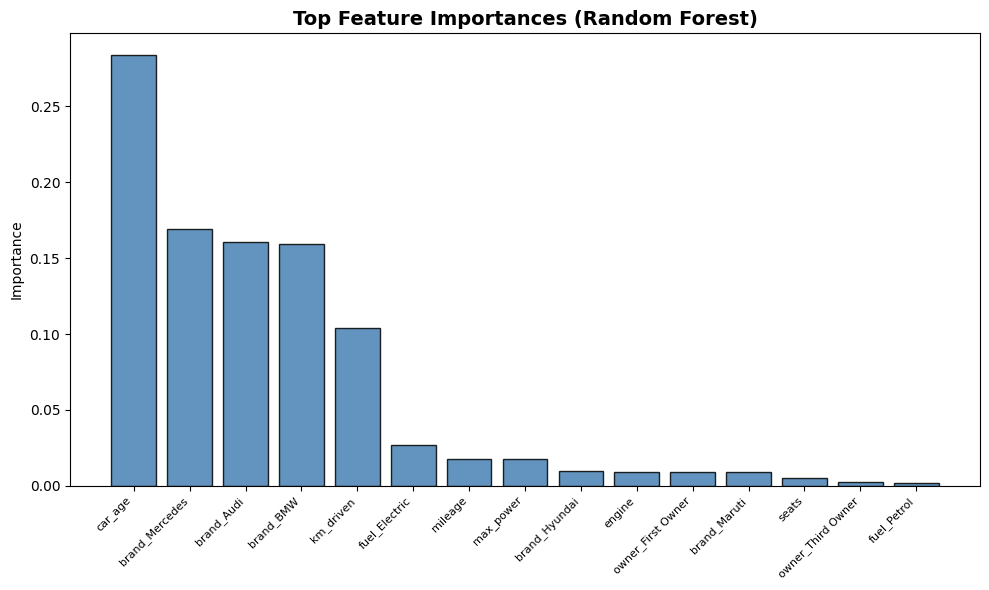

In [13]:
# 7. FEATURE IMPORTANCE
best_model_obj = results['Random Forest']['pipeline'].named_steps['model']
cat_feature_names = results['Random Forest']['pipeline'].named_steps['preprocessor']\
    .named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_feature_names = numerical_cols + cat_feature_names

importances = best_model_obj.feature_importances_
top_n = min(15, len(importances))
top_idx = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(10, 6))
plt.bar(range(top_n), importances[top_idx], color='steelblue', edgecolor='black', alpha=0.85)
plt.xticks(range(top_n), [all_feature_names[i] for i in top_idx], rotation=45, ha='right', fontsize=8)
plt.title('Top Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.ylabel('Importance')
plt.tight_layout()
plt.savefig('car_feature_importance.png', dpi=150, bbox_inches='tight')
print("    Saved: car_feature_importance.png")

In [14]:
# 8. PREDICTION DEMO
print("\n[8] Sample Prediction:")
sample_input = X_test.iloc[:5].copy()
sample_preds = best['pipeline'].predict(sample_input)
for i, (actual, pred) in enumerate(zip(y_test.iloc[:5], sample_preds)):
    print(f"    Sample {i+1}: Actual ₹{actual:,.0f}  |  Predicted ₹{pred:,.0f}")

print("\n" + "=" * 60)
print("  CAR PRICE PREDICTION COMPLETE!")
print("=" * 60)


[8] Sample Prediction:
    Sample 1: Actual ₹274,481  |  Predicted ₹274,562
    Sample 2: Actual ₹218,441  |  Predicted ₹287,063
    Sample 3: Actual ₹66,680  |  Predicted ₹141,042
    Sample 4: Actual ₹228,887  |  Predicted ₹258,746
    Sample 5: Actual ₹50,000  |  Predicted ₹58,998

  CAR PRICE PREDICTION COMPLETE!
